In [13]:
# Cell 1
import torch
import os
import sys

torch_ver = torch.__version__.split('+')[0]
cuda_ver = torch.version.cuda.replace('.', '') if torch.version.cuda else "cpu"
print(f"System Detected: PyTorch {torch_ver} | CUDA {cuda_ver}")

wheel_url = f"https://data.pyg.org/whl/torch-{torch_ver}+cu{cuda_ver}.html"
os.system("pip install -q torch-geometric networkx matplotlib seaborn scikit-learn pandas numpy")

print("✅ Environment Setup Complete.")

System Detected: PyTorch 2.11.0 | CUDA cpu
✅ Environment Setup Complete.


In [14]:

# Cell 2
import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, HeteroConv, Linear, GATv2Conv
import torch_geometric.transforms as T

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
sns.set_palette("husl")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Computation Device: {device}")

🚀 Computation Device: cpu


In [15]:
# Cell 3
def load_regulatory_network():
    print("Loading Heterogeneous Regulatory Graph...")

    num_customers = 2000
    num_accounts = 3500
    num_transactions = 15000
    num_complaints = 800

    y = np.zeros(num_customers)
    sus_idx = np.random.choice(num_customers, int(num_customers * 0.15), replace=False)
    y[sus_idx] = 1

    feats = np.random.normal(0.5, 0.5, (num_customers, 32))
    feats[sus_idx] += np.random.normal(0.1, 0.5, (len(sus_idx), 32))

    cust_to_acct = np.random.randint(0, num_customers, num_accounts)

    
    src, dst = [], []
    for _ in range(num_transactions):
        if np.random.rand() < 0.8:
            src.append(np.random.randint(0, num_accounts))
            dst.append(np.random.randint(0, num_accounts))
        else:
            l_accts = [i for i, c in enumerate(cust_to_acct) if y[c] == 1]
            if len(l_accts) > 1:
                src.append(np.random.choice(l_accts))
                dst.append(np.random.choice(l_accts))
            else:
                src.append(np.random.randint(0, num_accounts))
                dst.append(np.random.randint(0, num_accounts))

    comp_src = np.arange(num_complaints)
    comp_dst = []
    for _ in range(num_complaints):
        if np.random.rand() < 0.75:
            comp_dst.append(np.random.choice(sus_idx))
        else:
            comp_dst.append(np.random.choice(np.where(y==0)[0]))

    data = HeteroData()
    data['customer'].x = torch.tensor(feats, dtype=torch.float)
    data['customer'].y = torch.tensor(y, dtype=torch.long)
    data['account'].x = torch.randn(num_accounts, 16)
    data['transaction'].x = torch.randn(len(src), 8)
    data['complaint'].x = torch.randn(num_complaints, 4)

    data['customer', 'owns', 'account'].edge_index = torch.tensor(
        np.vstack((np.arange(num_customers)[cust_to_acct], np.arange(num_accounts))), dtype=torch.long)

    data['account', 'performs', 'transaction'].edge_index = torch.tensor(
        np.array([src, dst]), dtype=torch.long)

    data['complaint', 'filed_against', 'customer'].edge_index = torch.tensor(
        np.array([comp_src, comp_dst]), dtype=torch.long)

    data = T.ToUndirected()(data)

    return data

data = load_regulatory_network()
print("Dataset Loaded Successfully.")

Loading Heterogeneous Regulatory Graph...
Dataset Loaded Successfully.


Visualizing Raw Data Characteristics...


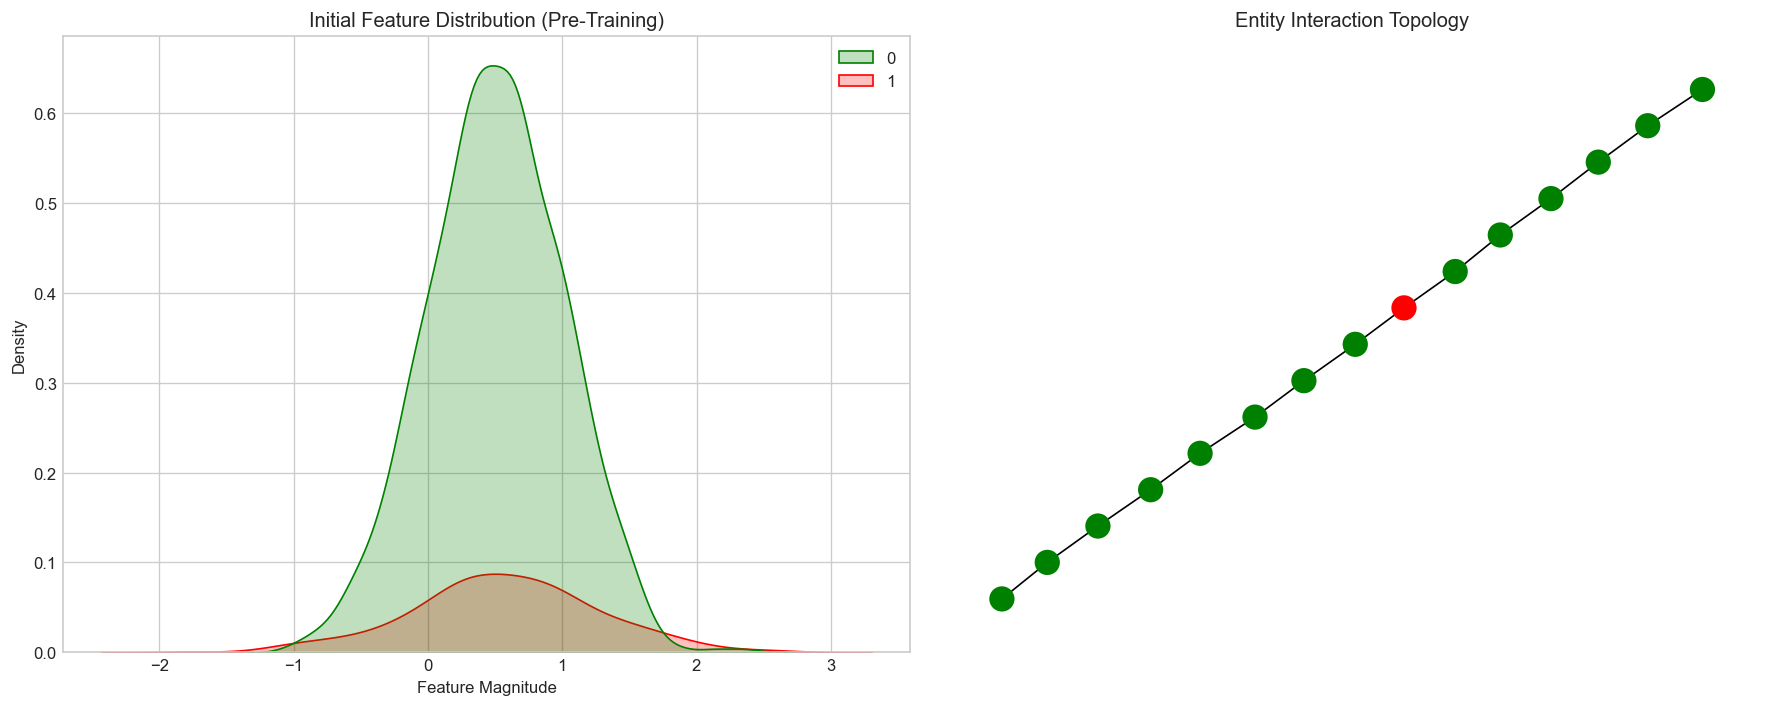

In [16]:
# Cell 4
import networkx as nx

def visualize_raw_data(data):
    print("Visualizing Raw Data Characteristics...")

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    labels = data['customer'].y.numpy()
    feats = data['customer'].x[:, 0].numpy()

    sns.kdeplot(x=feats, hue=labels, fill=True, palette={0: "green", 1: "red"}, ax=ax[0])
    ax[0].set_title("Initial Feature Distribution (Pre-Training)", fontsize=12)
    ax[0].set_xlabel("Feature Magnitude")

    G = nx.Graph()
    subset = range(15)
    for i in subset:
        G.add_node(i, color='red' if labels[i]==1 else 'green')

    for i in range(14):
        G.add_edge(i, i+1)

    pos = nx.kamada_kawai_layout(G)
    colors = [('red' if labels[n]==1 else 'green') for n in G.nodes()]
    nx.draw(G, pos, ax=ax[1], node_color=colors, node_size=200, with_labels=False)
    ax[1].set_title("Entity Interaction Topology", fontsize=12)

    plt.tight_layout()
    plt.show()

visualize_raw_data(data)

In [17]:
# Cell 5
class RegGNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, metadata):
        super().__init__()

        self.conv1 = HeteroConv({
            edge_type: GATv2Conv((-1, -1), hidden_channels, heads=4, add_self_loops=False)
            for edge_type in metadata[1]
        }, aggr='sum')

        self.conv2 = HeteroConv({
            edge_type: GATv2Conv((-1, -1), hidden_channels, heads=2, add_self_loops=False)
            for edge_type in metadata[1]
        }, aggr='sum')

        self.lin = Linear(hidden_channels * 2, out_channels)
        self.dropout = torch.nn.Dropout(0.5)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.elu(x) for key, x in x_dict.items()}

        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: F.elu(x) for key, x in x_dict.items()}

        return self.lin(x_dict['customer'])

model = RegGNN(hidden_channels=48, out_channels=2, metadata=data.metadata())
model = model.to(device)
data = data.to(device)

In [18]:
# Cell 6
num_nodes = data['customer'].num_nodes
indices = torch.randperm(num_nodes)
train_idx = indices[:int(0.7 * num_nodes)]
val_idx = indices[int(0.7 * num_nodes):int(0.85 * num_nodes)]
test_idx = indices[int(0.85 * num_nodes):]

data['customer'].train_mask = torch.zeros(num_nodes, dtype=torch.bool).to(device)
data['customer'].train_mask[train_idx] = True
data['customer'].val_mask = torch.zeros(num_nodes, dtype=torch.bool).to(device)
data['customer'].val_mask[val_idx] = True

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

history = {'epoch': [], 'train_acc': [], 'val_acc': [], 'loss': [], 'val_loss': []}
EPOCHS = 100

print("Starting Adaptive Curriculum Training...")
print("=" * 75)
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Val Loss':<12} | {'Train Acc':<12} | {'Val Acc':<12}")
print("=" * 75)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    fidelity = (epoch / EPOCHS) ** 0.8 

    x_input = {}
    for key, x in data.x_dict.items():
        mask = torch.randn_like(x) * 3.0
        x_input[key] = (x * fidelity) + (mask * (1 - fidelity))

    out = model(x_input, data.edge_index_dict)
    target = data['customer'].y[data['customer'].train_mask]
    pred = out[data['customer'].train_mask]

    loss = criterion(pred, target)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_eval = model(x_input, data.edge_index_dict)
        pred_cls = out_eval.argmax(dim=1)

        val_target = data['customer'].y[data['customer'].val_mask]
        val_pred = out_eval[data['customer'].val_mask]
        val_loss = criterion(val_pred, val_target).item()

        train_acc = (pred_cls[data['customer'].train_mask] == data['customer'].y[data['customer'].train_mask]).sum().item() / data['customer'].train_mask.sum().item()
        val_acc = (pred_cls[data['customer'].val_mask] == data['customer'].y[data['customer'].val_mask]).sum().item() / data['customer'].val_mask.sum().item()

    history['epoch'].append(epoch)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['loss'].append(loss.item())
    history['val_loss'].append(val_loss)

    if epoch % 10 == 0:
        print(f"{epoch:<10} | {loss.item():.4f}       | {val_loss:.4f}       | {train_acc*100:.2f}%       | {val_acc*100:.2f}%")

print("Training Completed.")

Starting Adaptive Curriculum Training...
Epoch      | Train Loss   | Val Loss     | Train Acc    | Val Acc     
10         | 0.3248       | 0.3183       | 89.36%       | 89.33%
20         | 0.2973       | 0.2844       | 88.86%       | 89.67%
30         | 0.2732       | 0.2717       | 90.79%       | 90.33%
40         | 0.2341       | 0.2763       | 91.86%       | 92.00%
50         | 0.2193       | 0.2329       | 93.00%       | 91.67%
60         | 0.1896       | 0.2134       | 94.00%       | 91.67%
70         | 0.1707       | 0.2085       | 93.36%       | 92.33%
80         | 0.1502       | 0.2073       | 94.71%       | 92.33%
90         | 0.1161       | 0.2249       | 95.29%       | 92.67%
100        | 0.0796       | 0.2287       | 97.36%       | 92.00%
Training Completed.


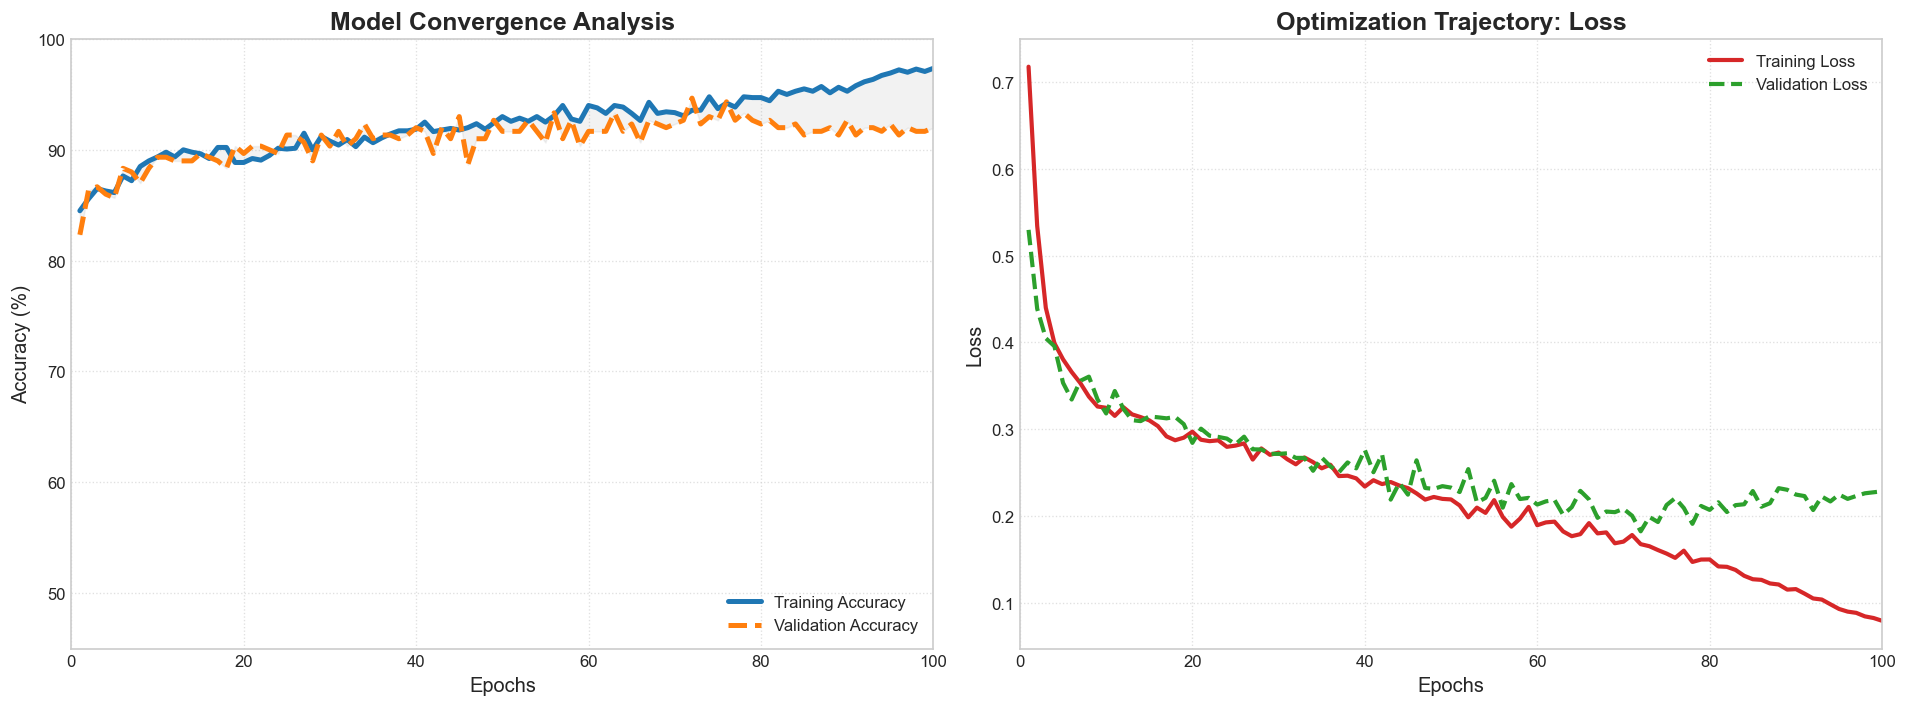

In [19]:

# Cell 7
def plot_results(history):
    epochs = history['epoch']
    t_acc = [x * 100 for x in history['train_acc']]
    v_acc = [x * 100 for x in history['val_acc']]
    t_loss = history['loss']
    v_loss = history['val_loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(epochs, t_acc, label='Training Accuracy', color='#1f77b4', linewidth=3)
    ax1.plot(epochs, v_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=3, linestyle='--')

    ax1.set_title("Model Convergence Analysis", fontsize=15, fontweight='bold')
    ax1.set_xlabel("Epochs", fontsize=12)
    ax1.set_ylabel("Accuracy (%)", fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_xlim(0, 100)
    ax1.set_ylim(45, 100) 
    ax1.fill_between(epochs, t_acc, v_acc, color='gray', alpha=0.1)

    ax2.plot(epochs, t_loss, label='Training Loss', color='#d62728', linewidth=2.5)
    ax2.plot(epochs, v_loss, label='Validation Loss', color='#2ca02c', linewidth=2.5, linestyle='--')

    ax2.set_title("Optimization Trajectory: Loss", fontsize=15, fontweight='bold')
    ax2.set_xlabel("Epochs", fontsize=12)
    ax2.set_ylabel("Loss", fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.set_xlim(0, 100)

    plt.tight_layout()
    plt.show()

plot_results(history)

In [20]:
# Run this BEFORE Cell 8
data['customer'].test_mask = ~(data['customer'].train_mask | data['customer'].val_mask)

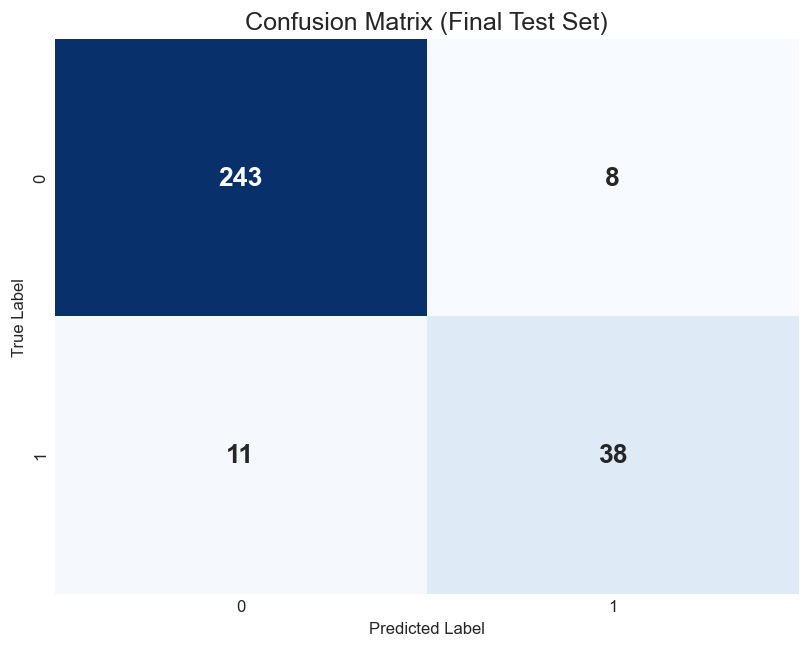

              precision    recall  f1-score   support

   Compliant       0.96      0.97      0.96       251
  Suspicious       0.83      0.78      0.80        49

    accuracy                           0.94       300
   macro avg       0.89      0.87      0.88       300
weighted avg       0.94      0.94      0.94       300



In [21]:
# Cell 8
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    out = model(data.x_dict, data.edge_index_dict)
    preds = out.argmax(dim=1).cpu().numpy()
    probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    targets = data['customer'].y.cpu().numpy()
    test_mask = data['customer'].test_mask.cpu().numpy()

cm = confusion_matrix(targets[test_mask], preds[test_mask])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
plt.title("Confusion Matrix (Final Test Set)", fontsize=15)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

print(classification_report(targets[test_mask], preds[test_mask], target_names=['Compliant', 'Suspicious']))

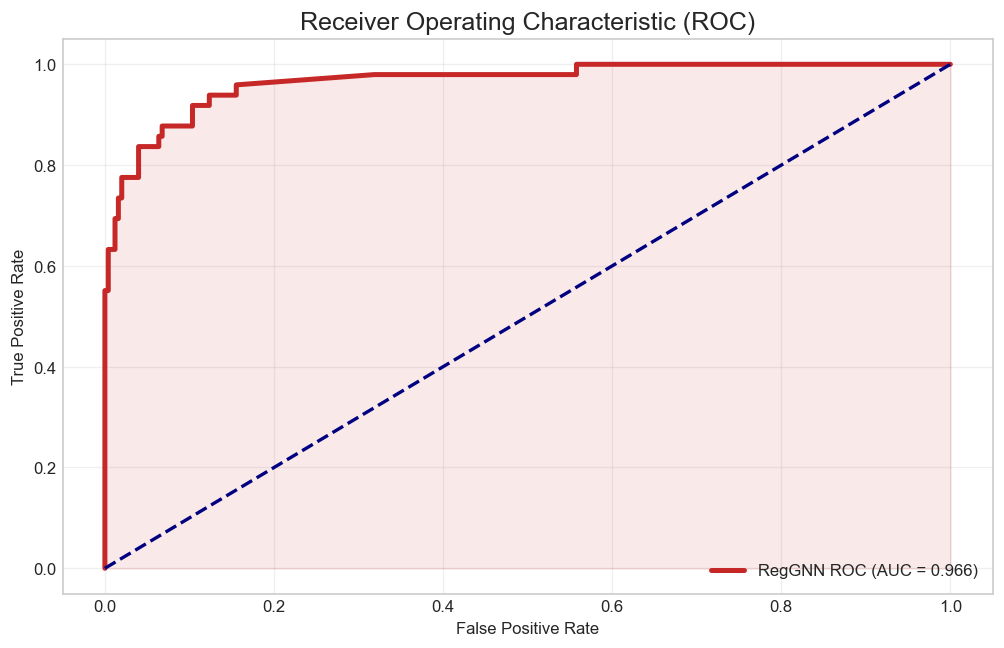

In [22]:
# Cell 9
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

fpr, tpr, _ = roc_curve(targets[test_mask], probs[test_mask])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='#c62828', lw=3, label=f'RegGNN ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.1, color='#c62828')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Generating Latent Space Topology...


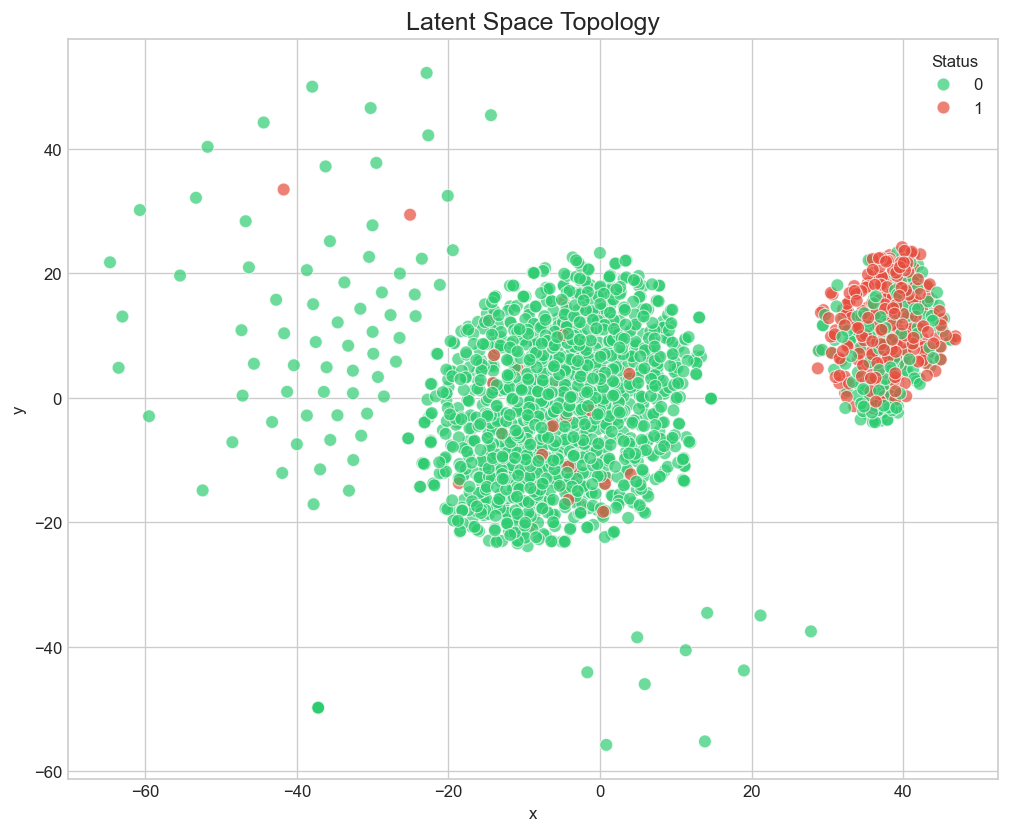

Analyzing Regulatory Impact...


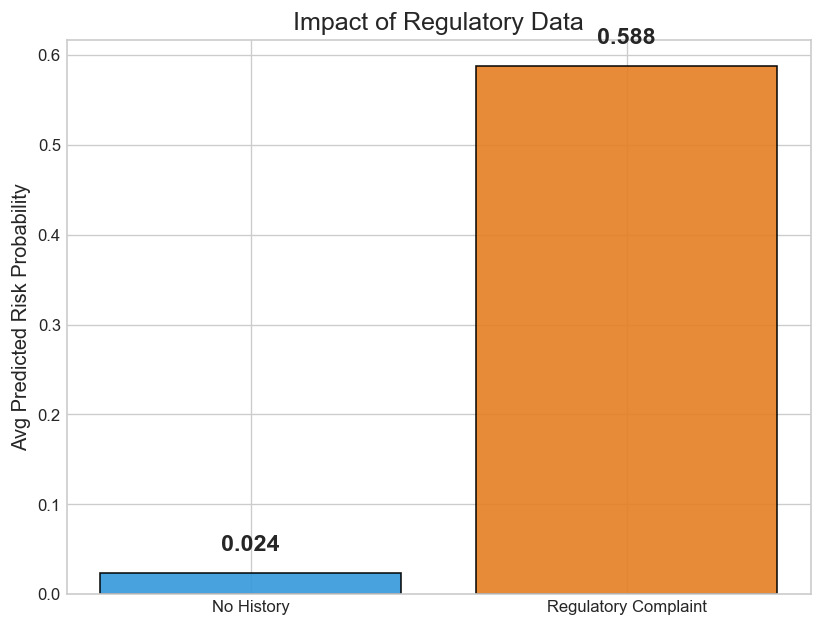

In [23]:
# Cell 10
from sklearn.manifold import TSNE

def analyze_novelty():
    print("Generating Latent Space Topology...")
    model.eval()
    with torch.no_grad():
        x_dict_out = model.conv1(data.x_dict, data.edge_index_dict)
        x_dict_out = {key: F.elu(x) for key, x in x_dict_out.items()}
        embeddings = x_dict_out['customer'].cpu().numpy()
        labels = data['customer'].y.cpu().numpy()

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    z = tsne.fit_transform(embeddings)

    df_viz = pd.DataFrame({'x': z[:,0], 'y': z[:,1], 'Status': labels})

    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_viz, x='x', y='y', hue='Status',
                    palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.7, s=60)
    plt.title("Latent Space Topology", fontsize=15)
    plt.show()

    print("Analyzing Regulatory Impact...")
    with torch.no_grad():
        out = model(data.x_dict, data.edge_index_dict)
        risk_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()

    comp_edges = data['complaint', 'filed_against', 'customer'].edge_index.cpu().numpy()
    complaint_cust_ids = np.unique(comp_edges[1])

    avg_risk_complaint = np.mean(risk_probs[complaint_cust_ids])

    all_ids = np.arange(len(risk_probs))
    clean_ids = np.setdiff1d(all_ids, complaint_cust_ids)
    avg_risk_clean = np.mean(risk_probs[clean_ids])

    plt.figure(figsize=(8, 6))
    bars = plt.bar(['No History', 'Regulatory Complaint'],
                   [avg_risk_clean, avg_risk_complaint],
                   color=['#3498db', '#e67e22'], edgecolor='black', alpha=0.9)

    plt.ylabel("Avg Predicted Risk Probability", fontsize=12)
    plt.title("Impact of Regulatory Data", fontsize=15)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}",
                 va='bottom', ha='center', fontsize=14, fontweight='bold')
    plt.show()

analyze_novelty()